<a href="https://colab.research.google.com/github/zhouqic4/MSSP607-GitHub/blob/main/Assignments/Assignment%201/zc_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data_folder = '/content/drive/MyDrive/mssp607/Assignments/Assignment 1/data/'
fig_folder = '/content/drive/MyDrive/mssp607/Assignments/Assignment 1/figures/'

# **WORK BEFORE CODING**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
academic = pd.read_csv(data_folder + 'data_academic_performance.csv')
academic.shape

(12411, 45)

In [ ]:
academic.head()

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [ ]:
#data def for numericals
definitions=pd.read_csv(data_folder+ 'data_definitions_numerical.csv')
definitions

,Variable,Full name
0,MAT_S11,Mathematics
1,CR_S11,Critical Reading
2,CC_S11,Citizen Competencies S11
3,BIO_S11,Biology
4,ENG_S11,English
5,QR_PRO,Quantitative Reasoning
6,CR_PRO,Critical Reading
7,CC_PRO,Citizen Competencies SPRO
8,ENG_PRO,English
9,WC_PRO,Written Communication


In [ ]:
academic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   COD_S11           12411 non-null  object 
 1   GENDER            12411 non-null  object 
 2   EDU_FATHER        12411 non-null  object 
 3   EDU_MOTHER        12411 non-null  object 
 4   OCC_FATHER        12411 non-null  object 
 5   OCC_MOTHER        12411 non-null  object 
 6   STRATUM           12411 non-null  object 
 7   SISBEN            12411 non-null  object 
 8   PEOPLE_HOUSE      12411 non-null  object 
 9   Unnamed: 9        0 non-null      float64
 10  INTERNET          12411 non-null  object 
 11  TV                12411 non-null  object 
 12  COMPUTER          12411 non-null  object 
 13  WASHING_MCH       12411 non-null  object 
 14  MIC_OVEN          12411 non-null  object 
 15  CAR               12411 non-null  object 
 16  DVD               12411 non-null  object

In [ ]:

#data clean
print('Non-empty values in Unnamed: 9:', academic['Unnamed: 9'].count())
del academic['Unnamed: 9']

text_cols = ['EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER', 'OCC_MOTHER', 'STRATUM', 'SISBEN',
             'PEOPLE_HOUSE', 'REVENUE', 'JOB']
for col in text_cols:
    academic[col] = academic[col].apply(lambda x: x.strip())

print('\nNumber of "0" (missing) values per column:')
print((academic[text_cols] == '0').sum())
academic[text_cols] = academic[text_cols].replace('0', np.nan)

print('\nWC_PRO scores equal to 0:', (academic['WC_PRO'] == 0).sum())
academic['WC_PRO_valid'] = academic['WC_PRO'].replace(0, np.nan)

Non-empty values in Unnamed: 9: 0

Number of "0" (missing) values per column:
EDU_FATHER      391
EDU_MOTHER      388
OCC_FATHER      940
OCC_MOTHER      313
STRATUM          14
SISBEN           21
PEOPLE_HOUSE     21
REVENUE         279
JOB             138
dtype: int64

WC_PRO scores equal to 0: 309


# **DATA CLEANING + LIMITATION**

In [ ]:
academic['EDU_FATHER'].fillna('Missing').value_counts()

,count
EDU_FATHER,
Complete professional education,3016
Complete Secundary,2843
Complete technique or technology,1194
Incomplete Secundary,1091
Postgraduate education,1085
Complete primary,824
Incomplete primary,735
Incomplete Professional Education,425
Not sure,407


In [ ]:
edu_number = {'Ninguno':0,
              'Incomplete primary': 1, 'Complete primary': 2,
              'Incomplete Secundary': 3, 'Complete Secundary': 4,
              'Incomplete technical or technological': 5, 'Complete technique or technology': 6,
              'Incomplete Professional Education': 7, 'Complete professional education': 8,
              'Postgraduate education': 9}
academic['EDU_FATHER_NUM'] = academic['EDU_FATHER'].apply(lambda x: edu_number.get(x, np.nan))
academic['EDU_MOTHER_NUM'] = academic['EDU_MOTHER'].apply(lambda x: edu_number.get(x, np.nan))

#Highest level of the two parents. Missing values are set to -1 first so max() can compare them.
parents = academic[['EDU_FATHER_NUM', 'EDU_MOTHER_NUM']].fillna(-1)
academic['EDU_PARENT_NUM'] = parents.apply(lambda row: max(row), axis=1).replace(-1, np.nan)

#group to 5
edu_group = {0: 'None/Primary', 1: 'None/Primary', 2: 'None/Primary',
             3: 'Secondary', 4: 'Secondary',
             5: 'Technical', 6: 'Technical',
             7: 'University', 8: 'University',
             9: 'Postgraduate'}
academic['EDU_PARENT'] = academic['EDU_PARENT_NUM'].apply(lambda x: edu_group.get(x, np.nan))
edu_order = ['None/Primary', 'Secondary', 'Technical', 'University', 'Postgraduate']

#High school average of the 5 SABER 11 subjects (like the 'total score' in the example)
s11_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11']
pro_cols = ['QR_PRO', 'CR_PRO', 'CC_PRO', 'WC_PRO_valid', 'ENG_PRO', 'FEP_PRO']
academic['S11_AVG'] = (academic['MAT_S11'] + academic['CR_S11'] + academic['CC_S11']
                       + academic['BIO_S11'] + academic['ENG_S11']) / 5

academic['EDU_PARENT'].fillna('Missing').value_counts()


,count
EDU_PARENT,
University,4284
Secondary,3490
Technical,1688
Postgraduate,1586
None/Primary,918
Missing,445


# **SUMMARY OF NUMERICALS**

In [ ]:
scores = s11_cols + ['QR_PRO', 'CR_PRO', 'CC_PRO', 'WC_PRO', 'ENG_PRO', 'FEP_PRO', 'G_SC']
academic[scores].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
MAT_S11,12411.0,64.3,11.9,26.0,56.0,64.0,72.0,100.0
CR_S11,12411.0,60.8,10.0,24.0,54.0,61.0,67.0,100.0
CC_S11,12411.0,60.7,10.1,0.0,54.0,60.0,67.0,100.0
BIO_S11,12411.0,64.0,11.2,11.0,56.0,64.0,71.0,100.0
ENG_S11,12411.0,61.8,14.3,26.0,50.0,59.0,72.0,100.0
QR_PRO,12411.0,77.4,22.7,1.0,65.0,85.0,96.0,100.0
CR_PRO,12411.0,62.2,27.7,1.0,42.0,67.0,86.0,100.0
CC_PRO,12411.0,59.2,29.0,1.0,36.0,65.0,85.0,100.0
WC_PRO,12411.0,53.7,30.0,0.0,28.0,56.0,80.0,100.0
ENG_PRO,12411.0,67.5,25.5,1.0,51.0,74.0,88.0,100.0


## **SAMPLE COMPOSITION** : **How many students are in each category?**

In [ ]:
for col in ['GENDER', 'STRATUM', 'SCHOOL_NAT', 'EDU_PARENT']:
  counts = academic[col].fillna('Missing').value_counts()
  percent = (counts / len(academic)*100).round(1)
  print(pd.DataFrame({'count': counts, 'percent': percent}), '\n')

        count  percent
GENDER                
M        7368     59.4
F        5043     40.6 

           count  percent
STRATUM                  
Stratum 3   4045     32.6
Stratum 2   4029     32.5
Stratum 1   1709     13.8
Stratum 4   1578     12.7
Stratum 5    633      5.1
Stratum 6    403      3.2
Missing       14      0.1 

            count  percent
SCHOOL_NAT                
PRIVATE      6565     52.9
PUBLIC       5846     47.1 

              count  percent
EDU_PARENT                  
University     4284     34.5
Secondary      3490     28.1
Technical      1688     13.6
Postgraduate   1586     12.8
None/Primary    918      7.4
Missing         445      3.6 



# **AVERAGE OF EACH SCORE BY GENDER**

In [ ]:
academic.groupby('GENDER')[s11_cols + pro_cols + ['G_SC']].mean().round(1)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,WC_PRO_valid,ENG_PRO,FEP_PRO,G_SC
GENDER,,,,,,,,,,,,
F,61.9,60.9,60.0,62.3,61.5,71.9,61.3,58.6,57.6,66.5,145.3,161.3
M,66.0,60.7,61.2,65.1,62.0,81.2,62.8,59.6,53.3,68.2,145.6,163.7


# **AVERAGE OF EVERY SCORE BY STRATUM**



In [ ]:
academic.groupby('STRATUM')[s11_cols + pro_cols + ['G_SC']].mean().round(1)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,WC_PRO_valid,ENG_PRO,FEP_PRO,G_SC
STRATUM,,,,,,,,,,,,
Stratum 1,59.8,57.1,57.3,60.2,53.4,70.5,53.6,50.9,50.7,50.9,143.0,152.4
Stratum 2,62.1,59.1,59.2,62.1,57.2,74.6,58.8,56.0,52.6,60.9,142.5,158.2
Stratum 3,64.3,61.5,61.3,64.0,62.4,78.3,63.9,60.2,54.4,70.6,142.2,163.8
Stratum 4,69.1,64.1,63.6,67.7,69.8,83.2,69.3,67.0,60.7,80.1,154.0,172.0
Stratum 5,72.1,65.5,64.9,71.0,77.0,86.7,71.7,69.2,64.6,87.0,160.4,177.4
Stratum 6,74.7,66.0,66.7,72.7,82.4,88.4,73.8,71.1,66.6,92.5,162.2,181.5


# **AVERAGE OF EVERY SCORE BY PARENTS' EDUCATION**


In [ ]:
academic.groupby('EDU_PARENT')[s11_cols + pro_cols + ['G_SC']].mean().loc[edu_order].round(1)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,WC_PRO_valid,ENG_PRO,FEP_PRO,G_SC
EDU_PARENT,,,,,,,,,,,,
None/Primary,60.3,57.6,57.9,60.7,54.8,72.1,55.6,53.0,52.1,54.4,140.7,154.4
Secondary,61.4,58.7,58.8,61.4,56.5,73.6,57.1,54.3,51.8,59.3,141.4,156.8
Technical,63.5,60.5,60.4,63.2,60.0,76.4,62.1,57.8,53.7,66.0,144.3,161.1
University,66.0,62.0,61.8,65.3,65.1,79.3,64.9,62.0,56.4,73.0,147.8,166.1
Postgraduate,70.9,65.2,64.9,69.6,71.9,85.8,71.9,69.3,62.6,81.9,154.1,175.3


# **AVERAGE OF EACH SCORE BY TYPE OF HIGH SCHOOL**

In [ ]:
academic.groupby('SCHOOL_NAT')[s11_cols + pro_cols + ['G_SC']].mean().round(1)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,WC_PRO_valid,ENG_PRO,FEP_PRO,G_SC
SCHOOL_NAT,,,,,,,,,,,,
PRIVATE,66.9,62.6,62.3,66.1,67.1,80.7,66.2,62.9,58.5,75.9,147.5,168.2
PUBLIC,61.4,58.8,58.9,61.6,55.9,73.7,57.7,55.0,51.2,58.1,143.2,156.5


**1. Does parental education influence outcomes, and if so, how much?**

In [ ]:
grouped = academic.groupby('EDU_PARENT')
q1 = grouped['G_SC'].agg(['count', 'mean', 'std']).loc[edu_order]
q1['S11_AVG'] = grouped['S11_AVG'].mean()
q1['QR_PRO'] = grouped['QR_PRO'].mean()
q1['ENG_PRO'] = grouped['ENG_PRO'].mean()
q1['difference'] = q1['mean'] - q1['mean'].iloc[0]
q1.round(1)

,count,mean,std,S11_AVG,QR_PRO,ENG_PRO,difference
EDU_PARENT,,,,,,,
None/Primary,918,154.4,22.0,58.3,72.1,54.4,0.0
Secondary,3490,156.8,21.9,59.4,73.6,59.3,2.4
Technical,1688,161.1,21.7,61.5,76.4,66.0,6.7
University,4284,166.1,22.8,64.0,79.3,73.0,11.7
Postgraduate,1586,175.3,22.0,68.5,85.8,81.9,20.9


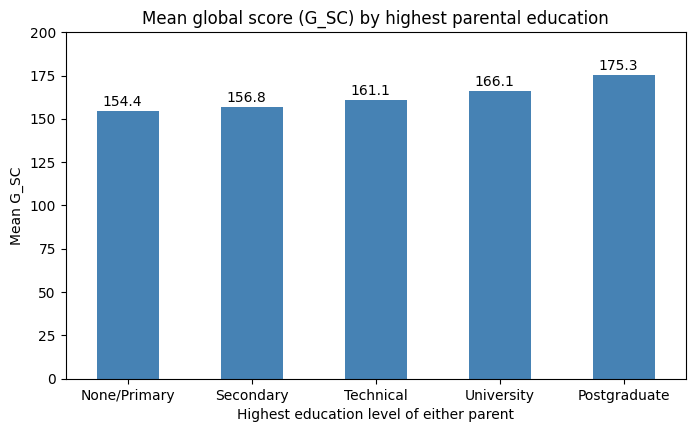

In [ ]:
#parental education's mean global score
q1['mean'].plot(kind='bar', color='steelblue', figsize=(8, 4.5), rot=0,
                title='Mean global score (G_SC) by highest parental education')
plt.xlabel('Highest education level of either parent')
plt.ylabel('Mean G_SC')
plt.ylim(0, 200)
for i, value in enumerate(q1['mean']):
    plt.text(i - 0.2, value + 3, round(value, 1))
plt.savefig(fig_folder + 'fig1_parental_education.png')
plt.show()

In [ ]:
#correlation btw education and the gsc
academic[['EDU_FATHER_NUM', 'EDU_MOTHER_NUM', 'EDU_PARENT_NUM', 'G_SC']].corr().round(3)

,EDU_FATHER_NUM,EDU_MOTHER_NUM,EDU_PARENT_NUM,G_SC
EDU_FATHER_NUM,1.000,0.640,0.836,0.261
EDU_MOTHER_NUM,0.640,1.000,0.871,0.266
EDU_PARENT_NUM,0.836,0.871,1.000,0.261
G_SC,0.261,0.266,0.261,1.000


In [ ]:
#students of more educated parents also had higher high school scores being inferred by last S11_AVG
academic['S11_QUARTILE'] = pd.qcut(academic['S11_AVG'], 4, labels=False) + 1
q1_by_quartile = academic.pivot_table(index='S11_QUARTILE', columns='EDU_PARENT', values='G_SC',
                                      aggfunc='mean')[edu_order]
q1_by_quartile['difference'] = q1_by_quartile['Postgraduate'] - q1_by_quartile['None/Primary']
q1_by_quartile.round(1)

EDU_PARENT,None/Primary,Secondary,Technical,University,Postgraduate,difference
S11_QUARTILE,,,,,,
1,137.4,138.6,141.4,140.1,142.4,5.0
2,156.2,156.3,155.5,157.2,157.4,1.2
3,166.9,168.7,168.9,169.5,172.2,5.4
4,184.6,183.5,184.2,186.6,188.3,3.7


**2. Which groups/stratum performs best? Are there differences between groups/stratums?**

# **AVERAGE SCORE BY STRATUM**

In [ ]:
grouped = academic.groupby('STRATUM')
q2 = grouped['G_SC'].agg(['count', 'mean', 'std'])
q2['S11_AVG'] = grouped['S11_AVG'].mean()
q2['QR_PRO'] = grouped['QR_PRO'].mean()
q2['CR_PRO'] = grouped['CR_PRO'].mean()
q2['ENG_PRO'] = grouped['ENG_PRO'].mean()
q2['percent'] = q2['count'] / q2['count'].sum() * 100
q2.round(1)

,count,mean,std,S11_AVG,QR_PRO,CR_PRO,ENG_PRO,percent
STRATUM,,,,,,,,
Stratum 1,1709,152.4,21.9,57.6,70.5,53.6,50.9,13.8
Stratum 2,4029,158.2,22.3,59.9,74.6,58.8,60.9,32.5
Stratum 3,4045,163.8,21.7,62.7,78.3,63.9,70.6,32.6
Stratum 4,1578,172.0,21.5,66.9,83.2,69.3,80.1,12.7
Stratum 5,633,177.4,21.5,70.1,86.7,71.7,87.0,5.1
Stratum 6,403,181.5,21.9,72.5,88.4,73.8,92.5,3.3


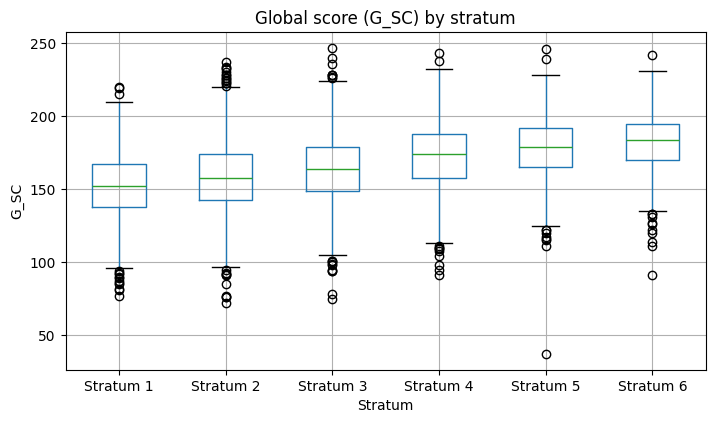

In [ ]:
academic.boxplot(column='G_SC', by='STRATUM', figsize=(8, 4.5))
plt.suptitle('')
plt.title('Global score (G_SC) by stratum')
plt.xlabel('Stratum')
plt.ylabel('G_SC')
plt.savefig(fig_folder + 'fig2_stratum_boxplot.png')
plt.show()

In [ ]:
#Difference btw the best and the worst
q2_sorted = q2.sort_values('mean')
worst = q2_sorted.index[0]
best = q2_sorted.index[-1]
print('Best stratum:', best, round(q2.loc[best, 'mean'], 1))
print('Worst stratum:', worst, round(q2.loc[worst, 'mean'], 1))
print('Difference:', round(q2.loc[best, 'mean'] - q2.loc[worst, 'mean'], 1), 'points')
print('Standard deviation of G_SC for all students:', round(academic['G_SC'].std(), 1))

Best stratum: Stratum 6 181.5
Worst stratum: Stratum 1 152.4
Difference: 29.2 points
Standard deviation of G_SC for all students: 23.1


In [ ]:
#from avg of stratum, we know english has the biggest difference btw stata
academic.groupby('STRATUM')[['ENG_S11', 'ENG_PRO']].mean().round(1)

,ENG_S11,ENG_PRO
STRATUM,,
Stratum 1,53.4,50.9
Stratum 2,57.2,60.9
Stratum 3,62.4,70.6
Stratum 4,69.8,80.1
Stratum 5,77.0,87.0
Stratum 6,82.4,92.5


In [ ]:
#some other socioeconomic factors- GSC by: SEL; SEL_IHE
print('SEL (student)')
print(academic.groupby('SEL')['G_SC'].agg(['count', 'mean', 'std']).round(1), '\n')
print('SEL_IHE (university)')
print(academic.groupby('SEL_IHE')['G_SC'].agg(['count', 'mean', 'std']).round(1))

SEL (student)
     count   mean   std
SEL                    
1     2138  155.5  21.8
2     4742  158.5  22.3
3     1491  162.3  22.0
4     4040  171.6  22.3 

SEL_IHE (university)
         count   mean   std
SEL_IHE                    
1         1137  153.1  20.6
2         7748  158.3  22.3
3          834  164.8  17.2
4         2692  178.8  20.2


**3. How does each gender perform in the global assessment?**

# **GLOBAL SCORE BY GENDER**

In [ ]:
academic.groupby('GENDER')['G_SC'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
GENDER,,,,,,,,
F,5043.0,161.3,22.3,76.0,146.0,162.0,177.0,242.0
M,7368.0,163.7,23.6,37.0,147.0,164.0,180.0,247.0


# **AVERAGE SOCRES BY GENDER**

In [ ]:
q3 = academic.groupby('GENDER')[s11_cols + pro_cols + ['G_SC']].mean().T
q3['difference (M-F)'] = q3['M'] - q3['F']
q3.round(2)

GENDER,F,M,difference (M-F)
MAT_S11,61.93,65.96,4.02
CR_S11,60.90,60.70,-0.20
CC_S11,59.96,61.22,1.26
BIO_S11,62.27,65.10,2.83
ENG_S11,61.45,62.04,0.59
QR_PRO,71.89,81.20,9.31
CR_PRO,61.34,62.79,1.45
CC_PRO,58.57,59.61,1.03
WC_PRO_valid,57.60,53.32,-4.28
ENG_PRO,66.53,68.16,1.63


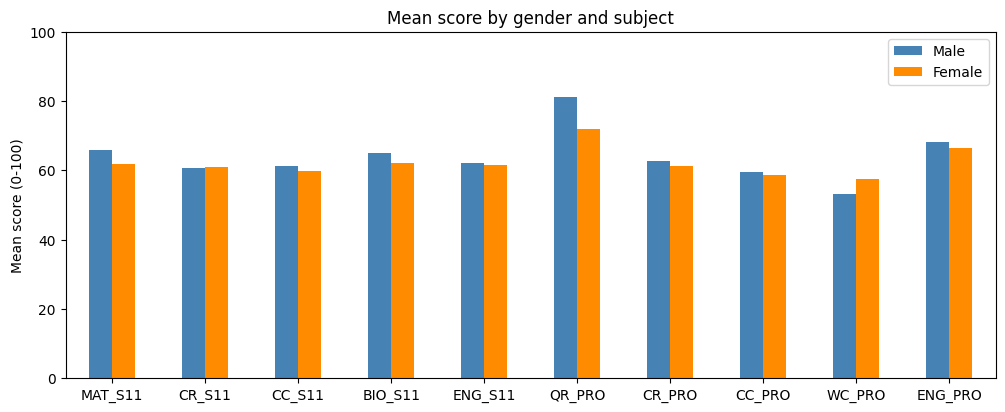

In [ ]:
#fig
subjects = s11_cols + ['QR_PRO', 'CR_PRO', 'CC_PRO', 'WC_PRO_valid', 'ENG_PRO']
ax = q3.loc[subjects, ['M', 'F']].plot(kind='bar', figsize=(12, 4.5), color=['steelblue', 'darkorange'],
                                       title='Mean score by gender and subject')
ax.set_xticklabels([s.replace('_valid', '') for s in subjects], rotation=0)
plt.ylabel('Mean score (0-100)')
plt.ylim(0, 100)
plt.legend(['Male', 'Female'])
plt.savefig(fig_folder + 'fig3_gender_means.png')
plt.show()

In [ ]:
#whether gender difference the same in every stratum
gender_stratum = academic.pivot_table(index='STRATUM', columns='GENDER', values = 'G_SC', aggfunc='mean')
gender_stratum['difference (M-F)'] = gender_stratum['M'] - gender_stratum['F']
gender_stratum.round(1)

GENDER,F,M,difference (M-F)
STRATUM,,,
Stratum 1,151.7,152.8,1.2
Stratum 2,157.3,158.8,1.5
Stratum 3,162.4,164.9,2.5
Stratum 4,170.6,173.0,2.4
Stratum 5,175.3,178.6,3.4
Stratum 6,179.0,182.7,3.7


In [ ]:
#share of each gender in each G_SC quartile (%)
quartile_counts = academic.pivot_table(index='GENDER', columns='QUARTILE', values='G_SC', aggfunc='count')
quartile_counts.apply(lambda x: x / x.sum() * 100, axis=1).round(1)

QUARTILE,1,2,3,4
GENDER,,,,
F,8.9,16.1,26.8,48.2
M,7.8,15.1,24.3,52.7


**4. Findings**

REVENUE, ACADEMIC PROGRAM, HIGH SCHOOL SCORES, z-scores

In [ ]:
#G_SC by revenue
revenue_order = ['less than 1 LMMW', 'Between 1 and less than 2 LMMW', 'Between 2 and less than 3 LMMW',
                 'Between 3 and less than 5 LMMW', 'Between 5 and less than 7 LMMW',
                 'Between 7 and less than 10 LMMW', '10 or more LMMW']
print(academic.groupby('REVENUE')['G_SC'].agg(['count', 'mean']).loc[revenue_order].round(1), '\n')
for col in ['SCHOOL_NAT', 'INTERNET', 'COMPUTER', 'JOB']:
    print(academic.groupby(col)['G_SC'].agg(['count', 'mean']).round(1), '\n')

                                 count   mean
REVENUE                                      
less than 1 LMMW                  1037  153.3
Between 1 and less than 2 LMMW    3873  156.8
Between 2 and less than 3 LMMW    2783  160.9
Between 3 and less than 5 LMMW    2239  165.3
Between 5 and less than 7 LMMW     973  170.9
Between 7 and less than 10 LMMW    509  176.2
10 or more LMMW                    718  183.7 

            count   mean
SCHOOL_NAT              
PRIVATE      6565  168.2
PUBLIC       5846  156.5 

          count   mean
INTERNET              
No         2659  154.6
Yes        9752  164.9 

          count   mean
COMPUTER              
No         2237  156.0
Yes       10174  164.2 

                                  count   mean
JOB                                           
No                                11909  163.0
Yes, 20 hours or more per week      134  156.0
Yes, less than 20 hours per week    230  155.1 



In [ ]:
#G_SC by academic program with 100 students at minimum
program_counts = academic['ACADEMIC_PROGRAM'].value_counts()
big_programs = program_counts[program_counts >= 100].index
programs = academic[academic['ACADEMIC_PROGRAM'].isin(big_programs)]
grouped = programs.groupby('ACADEMIC_PROGRAM')
program_table = grouped['G_SC'].agg(['count', 'mean'])
program_table['S11_AVG'] = grouped['S11_AVG'].mean()
program_table['percent_female'] = grouped['GENDER'].apply(lambda x: (x == 'F').mean() * 100)
program_table.sort_values('mean').round(1)

,count,mean,S11_AVG,percent_female
ACADEMIC_PROGRAM,,,,
INDUSTRIAL ENGINEERING,5318,159.0,60.5,52.0
CIVIL ENGINEERING,3320,161.1,61.4,35.9
MECHANICAL ENGINEERING,1135,166.1,64.8,12.1
ELECTRONIC ENGINEERING,849,166.9,65.1,19.6
ELECTRIC ENGINEERING,278,174.0,68.0,21.9
CHEMICAL ENGINEERING,1000,176.7,68.0,54.5


In [ ]:
#correlationship of high school scores to final global scores
academic[s11_cols + ['S11_AVG', 'G_SC']].corr()['G_SC'].round(2)

,G_SC
MAT_S11,0.64
CR_S11,0.65
CC_S11,0.63
BIO_S11,0.67
ENG_S11,0.66
S11_AVG,0.78
G_SC,1.00


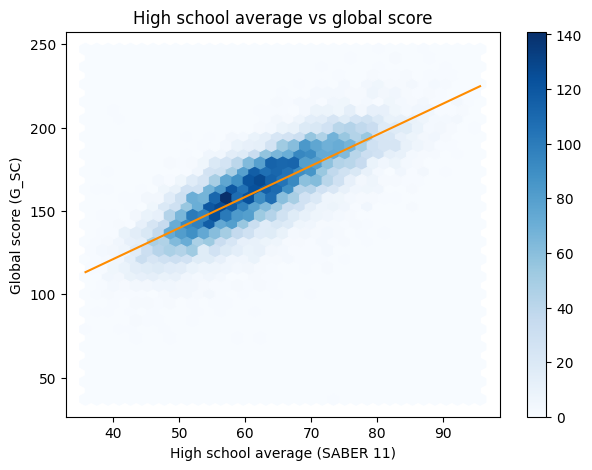

Each extra point of high school average goes with about 1.87 more G_SC points


In [ ]:
# trend line of high school avg as of G_SC point
ax = academic.plot(kind='hexbin', x='S11_AVG', y='G_SC', gridsize=35, cmap='Blues', figsize=(7, 5),
                   sharex=False, title='High school average vs global score')
slope, intercept = np.polyfit(academic['S11_AVG'], academic['G_SC'], 1)
x = np.linspace(academic['S11_AVG'].min(), academic['S11_AVG'].max(), 50)
ax.plot(x, slope * x + intercept, color='darkorange')
ax.set_xlabel('High school average (SABER 11)')
ax.set_ylabel('Global score (G_SC)')
plt.savefig(fig_folder + 'fig4_s11_vs_gsc.png')
plt.show()
print('Each extra point of high school average goes with about', round(slope, 2), 'more G_SC points')

# **MEAN Z_SCORES BY STRATUM**

In [ ]:
#Does the gap between strata get bigger or smaller during university?
#z = (x - mean) / standard deviation
for col in ['S11_AVG', 'G_SC', 'ENG_S11', 'ENG_PRO']:
    academic[col + '_Z'] = (academic[col] - academic[col].mean()) / academic[col].std()
z_means = academic.groupby('STRATUM')[['S11_AVG_Z', 'G_SC_Z', 'ENG_S11_Z', 'ENG_PRO_Z']].mean()
print(z_means.round(2))
print('\nGap between Stratum 6 and Stratum 1:')
print((z_means.loc['Stratum 6'] - z_means.loc['Stratum 1']).round(2))

           S11_AVG_Z  G_SC_Z  ENG_S11_Z  ENG_PRO_Z
STRATUM                                           
Stratum 1      -0.49   -0.45      -0.59      -0.65
Stratum 2      -0.25   -0.20      -0.32      -0.26
Stratum 3       0.04    0.05       0.04       0.12
Stratum 4       0.47    0.40       0.56       0.49
Stratum 5       0.81    0.64       1.06       0.77
Stratum 6       1.05    0.81       1.44       0.98

Gap between Stratum 6 and Stratum 1:
S11_AVG_Z    1.55
G_SC_Z       1.26
ENG_S11_Z    2.02
ENG_PRO_Z    1.63
dtype: float64


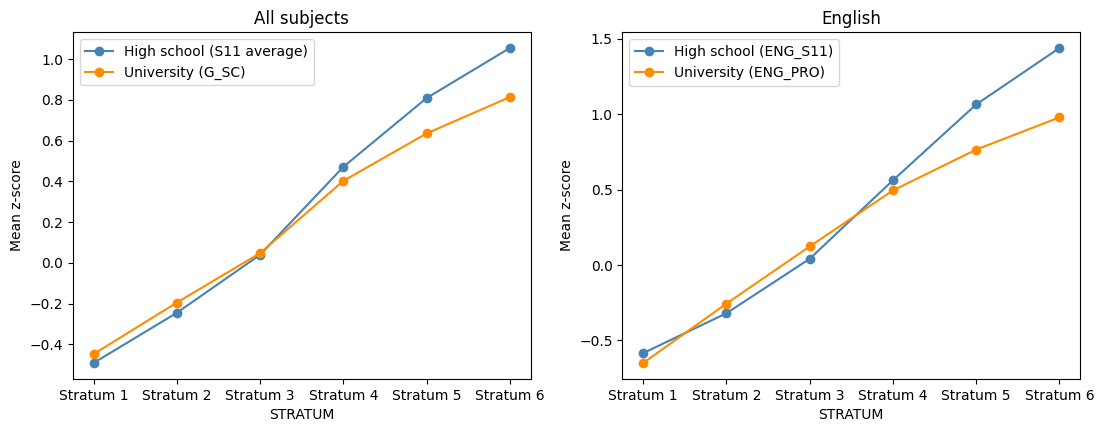

In [ ]:
#fig of zscore as of stratum
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
z_means[['S11_AVG_Z', 'G_SC_Z']].plot(ax=axes[0], marker='o', title='All subjects', rot=0,
                                      color=['steelblue', 'darkorange'])
z_means[['ENG_S11_Z', 'ENG_PRO_Z']].plot(ax=axes[1], marker='o', title='English', rot=0,
                                         color=['steelblue', 'darkorange'])
axes[0].legend(['High school (S11 average)', 'University (G_SC)'])
axes[1].legend(['High school (ENG_S11)', 'University (ENG_PRO)'])
axes[0].set_ylabel('Mean z-score')
axes[1].set_ylabel('Mean z-score')
plt.savefig(fig_folder + 'fig5_zscore_by_stratum.png')
plt.show()